In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# UTILIDADES: PSI & GRAFICOS

def calculate_psi(expected, actual, buckets=10):
    """Calcula PSI entre dos distribuciones univariadas."""
    expected_perc = np.histogram(expected, bins=buckets)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=buckets)[0] / len(actual)

    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi


def plot_feature_shift(X_val, X_drift, feature_names):
    n_features = X_val.shape[1]
    plt.figure(figsize=(15, 4 * n_features))

    for i in range(n_features):
        plt.subplot(n_features, 1, i+1)
        sns.kdeplot(X_val[:, i], label="Validación", fill=True)
        sns.kdeplot(X_drift[:, i], label="Monitoreo", fill=True)
        plt.title(f"Distribución del Feature {feature_names[i]}")
        plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:

# GENERACIÓN DE DATASET BASE
def generate_data():
    X, y = make_classification(
        n_samples=4000,
        n_features=5,
        n_informative=4,
        n_redundant=1,
        shift=0.0,
        scale=1.0,
        random_state=42
    )
    return train_test_split(X, y, test_size=0.3, random_state=42)


X_train, X_val, y_train, y_val = generate_data()
feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

In [ ]:
# MODELO BASELINE

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

baseline_preds = model.predict(X_val)
baseline_metrics = {
    "Accuracy": accuracy_score(y_val, baseline_preds),
    "F1": f1_score(y_val, baseline_preds)
}

print("\n=== MÉTRICAS BASE ===")
print(pd.DataFrame([baseline_metrics]))


=== MÉTRICAS BASE ===
   Accuracy        F1
0  0.961667  0.963082


In [ ]:
# SIMULACIÓN DE DATA DRIFT

def induce_drift(X):
    X_drift = X.copy()

    # mean shift
    X_drift[:, 0] += 1.2
    # scale drift
    X_drift[:, 1] *= 0.4
    # missing values injection
    mask = np.random.rand(X_drift.shape[0]) < 0.15
    X_drift[mask, 3] = 0

    return X_drift

X_drift = induce_drift(X_val)


In [ ]:
# EVALUACIÓN POST-DRIFT

drift_preds = model.predict(X_drift)
drift_metrics = {
    "Accuracy": accuracy_score(y_val, drift_preds),
    "F1": f1_score(y_val, drift_preds)
}

print("\n=== MÉTRICAS CON DRIFT ===")
print(pd.DataFrame([drift_metrics]))



=== MÉTRICAS CON DRIFT ===
   Accuracy        F1
0    0.8275  0.837901


In [ ]:
# COMPARACIÓN DE MÉTRICAS

comparison = pd.DataFrame({
    "Métrica": ["Accuracy", "F1"],
    "Base": list(baseline_metrics.values()),
    "Drift": list(drift_metrics.values())
})
comparison["Caída Relativa"] = (comparison["Base"] - comparison["Drift"]) / comparison["Base"]

print("\n=== COMPARACIÓN ===")
print(comparison)


=== COMPARACIÓN ===
    Métrica      Base     Drift  Caída Relativa
0  Accuracy  0.961667  0.827500        0.139515
1        F1  0.963082  0.837901        0.129979


In [ ]:
# DETECCIÓN ESTADÍSTICA (PSI + KS)

psi_scores = []
ks_scores = []

for i in range(X_val.shape[1]):
    psi_scores.append(calculate_psi(X_val[:, i], X_drift[:, i]))
    ks_scores.append(ks_2samp(X_val[:, i], X_drift[:, i]).pvalue)

stats_df = pd.DataFrame({
    "Feature": feature_names,
    "PSI": psi_scores,
    "KS p-value": ks_scores
})

print("\n=== DETECCIÓN ESTADÍSTICA ===")
print(stats_df)



=== DETECCIÓN ESTADÍSTICA ===
     Feature       PSI    KS p-value
0  feature_0  0.000000  1.767962e-74
1  feature_1  0.000000  2.332474e-35
2  feature_2  0.000000  1.000000e+00
3  feature_3  0.056579  1.859178e-06
4  feature_4  0.000000  1.000000e+00


In [ ]:
# SISTEMA DE ALERTAS

DRIFT_THRESHOLD = 0.1  # 10%
PSI_THRESHOLD = 0.2
KS_THRESHOLD = 0.05

metric_drift = any(comparison["Caída Relativa"] > DRIFT_THRESHOLD)
psi_alert = any(stats_df["PSI"] > PSI_THRESHOLD)
ks_alert = any(stats_df["KS p-value"] < KS_THRESHOLD)

if metric_drift or psi_alert or ks_alert:
    print("\n🚨 ALERTA DE DATA DRIFT 🚨")
    if metric_drift:
        print("- Degradación significativa en performance del modelo.")
    if psi_alert:
        print("- PSI indica drift importante en al menos un feature.")
    if ks_alert:
        print("- KS-test detecta cambio estadísticamente significativo.")
    print("\nAcciones sugeridas:")
    print("• Revisar pipeline de features")
    print("• Ejecutar retrain del modelo")
    print("• Evaluar si el cambio corresponde a estacionalidad real")
else:
    print("\n✔ No se detectó drift significativo.")


🚨 ALERTA DE DATA DRIFT 🚨
- Degradación significativa en performance del modelo.
- KS-test detecta cambio estadísticamente significativo.

Acciones sugeridas:
• Revisar pipeline de features
• Ejecutar retrain del modelo
• Evaluar si el cambio corresponde a estacionalidad real


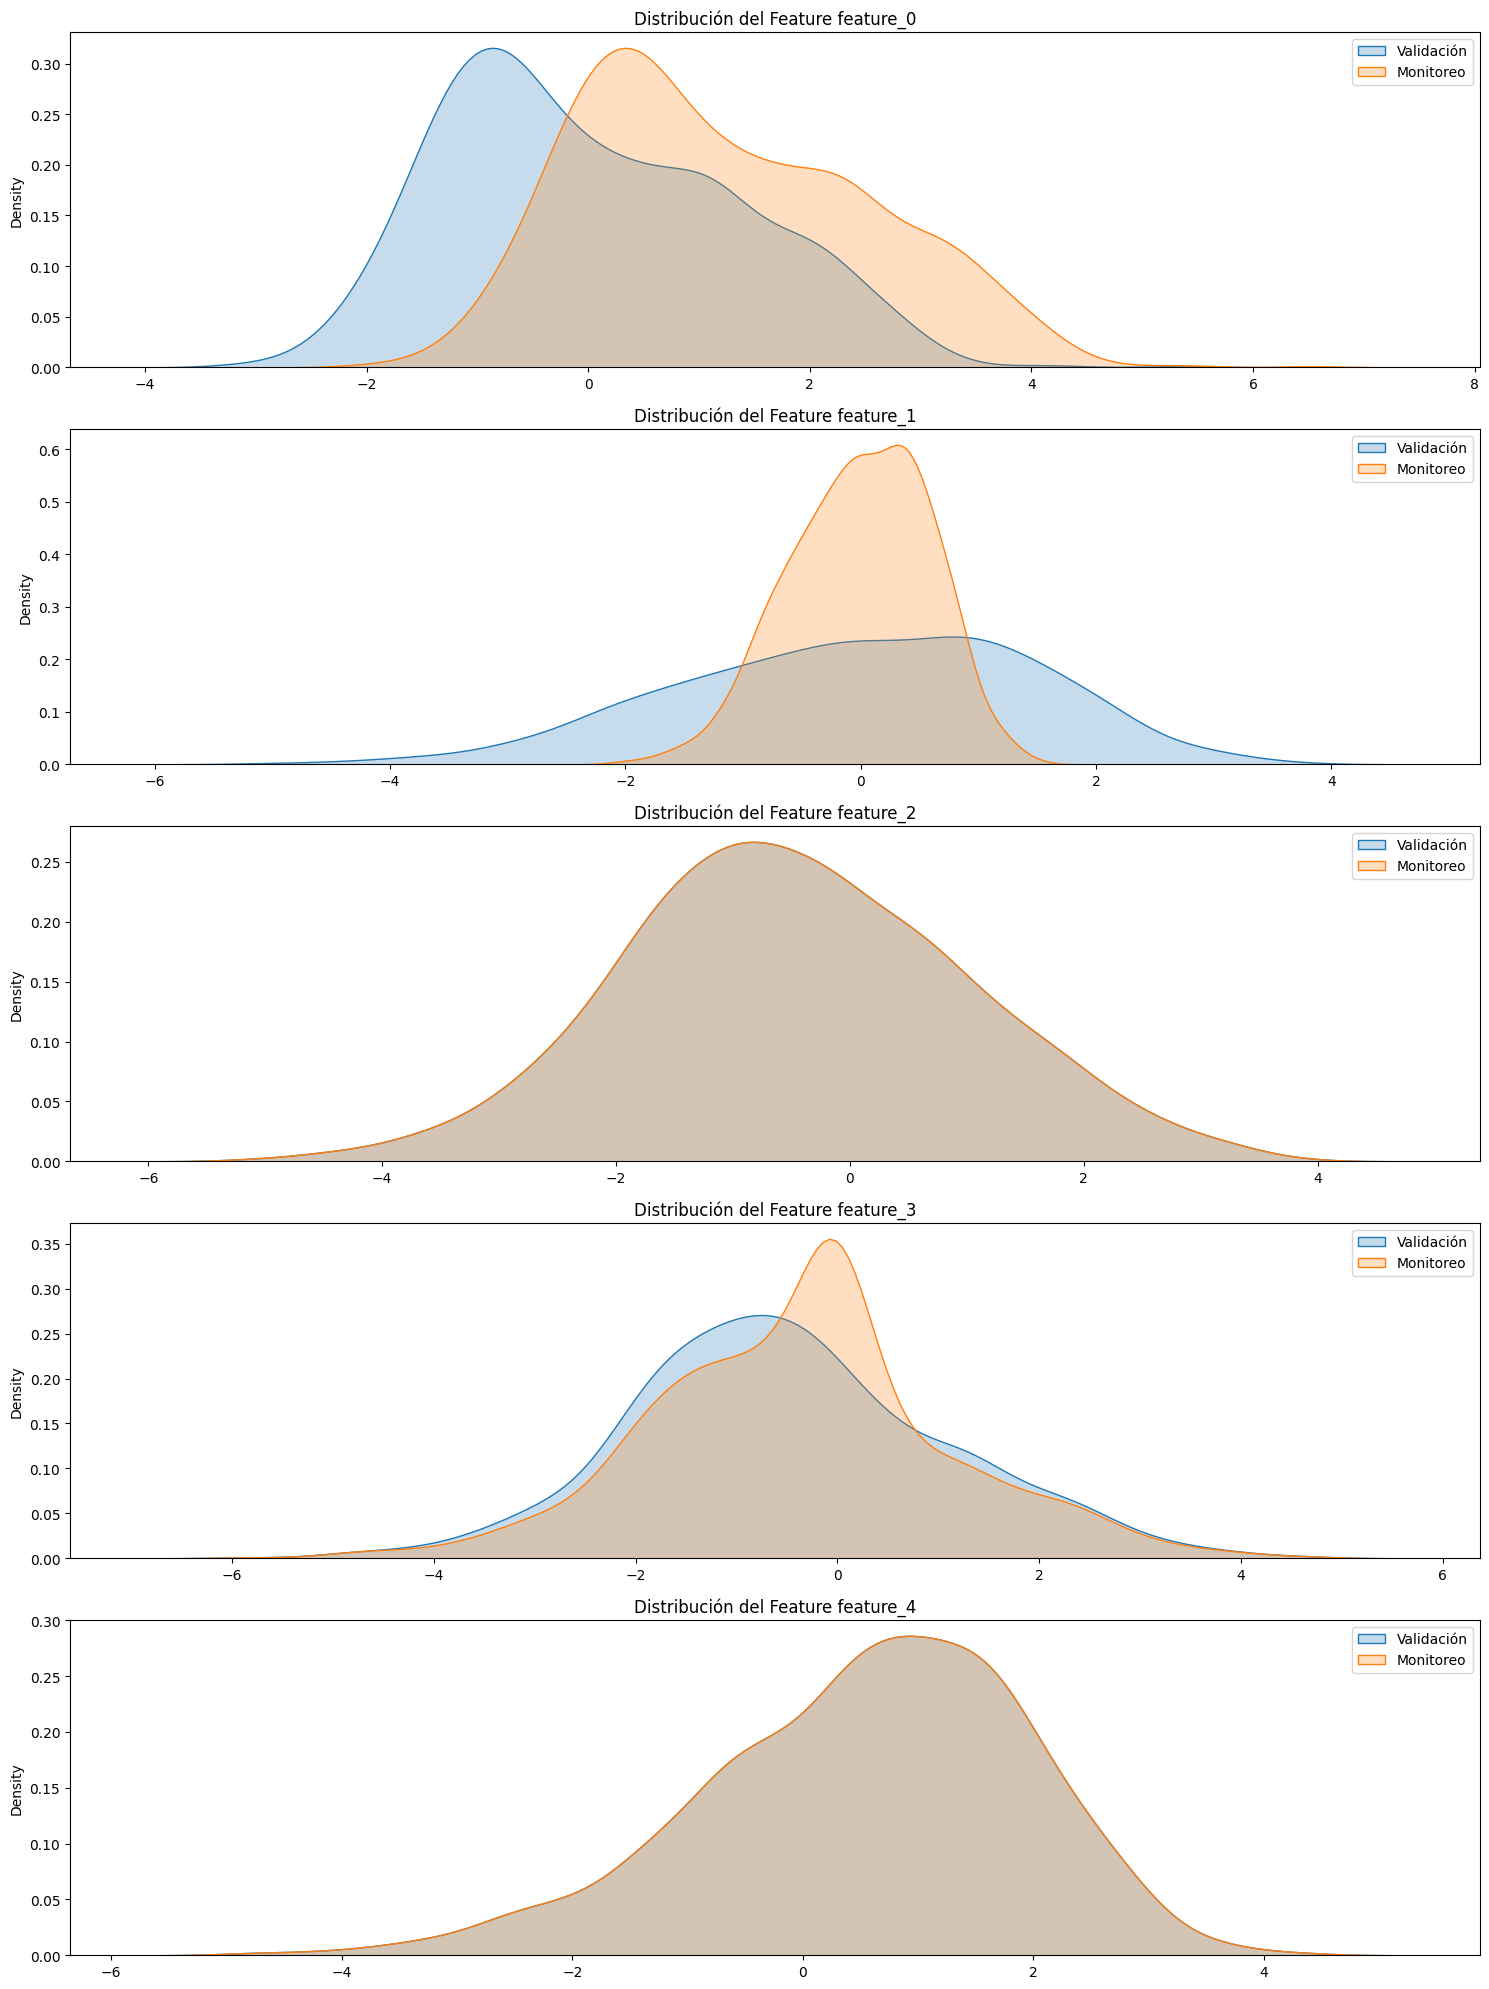

In [ ]:
# GRAFICOS

plot_feature_shift(X_val, X_drift, feature_names)